In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score
import joblib

In [11]:
df = pd.read_csv("data/titanic.csv")

In [12]:
X = df[['Sex']]  # Genre et classe du ticket
y = df['Survived']          # Variable cible

# Encoder la variable 'Sex' (male/female -> 0/1)
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])

# Split stratifié (important car le taux de survie est déséquilibré)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=78,      # reproductibilité
    stratify=y            # préserve le ratio survivants/non-survivants
)

print(f"Taille train: {len(X_train)}")
print(f"Taille test: {len(X_test)}")
print(f"Distribution train: {y_train.value_counts(normalize=True)}")
print(f"Distribution test: {y_test.value_counts(normalize=True)}")

Taille train: 712
Taille test: 179
Distribution train: Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Distribution test: Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


C:\Users\HighA\AppData\Local\Temp\ipykernel_31996\3118243257.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = le.fit_transform(X['Sex'])


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(solver="liblinear", class_weight="balanced")
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


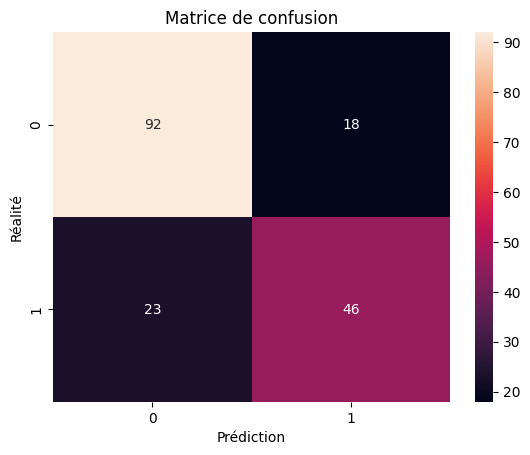

In [14]:
y_pred = model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion")
plt.show()

In [15]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Accuracy : 0.770949720670391
Precision : 0.71875
Recall : 0.6666666666666666
F1-score : 0.6917293233082706


In [16]:
joblib.dump(model, "models/ml_model.pkl")
joblib.dump(scaler, "models/ml_scaler.pkl")

['models/ml_scaler.pkl']